## 1. Загрузка данных

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
    VotingClassifier
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
TARGET = 'Transported'
train = pd.read_csv(f'spaceship-titanic/train.csv')
test = pd.read_csv(f'spaceship-titanic/test.csv')
sample_submission = pd.read_csv(f'spaceship-titanic/sample_submission.csv')
print('Train:', train.shape)
print('Test:', test.shape)
train.head()

Train: (8693, 14)
Test: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## 2. Первичный анализ данных

In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [8]:
display(train.describe().round(2))
display(train.isnull().sum().sort_values(ascending=False).to_frame('Количество пропусков'))
print('Всего пропусков:', train.isnull().sum().sum())
print('Полных дубликатов:', train.duplicated().sum())

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.00,8512.00,8510.00,8485.00,8510.00,8505.00
mean,28.83,224.69,458.08,173.73,311.14,304.85
std,14.49,666.72,1611.49,604.70,1136.71,1145.72
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,19.00,0.00,0.00,0.00,0.00,0.00
50%,27.00,0.00,0.00,0.00,0.00,0.00
75%,38.00,47.00,76.00,27.00,59.00,46.00
max,79.00,14327.00,29813.00,23492.00,22408.00,24133.00


,Количество пропусков
CryoSleep,217
ShoppingMall,208
VIP,203
HomePlanet,201
Name,200
Cabin,199
VRDeck,188
FoodCourt,183
Spa,183
Destination,182


Всего пропусков: 2324
Полных дубликатов: 0


Пропуски не удаляем, потому что тогда потеряется часть пассажиров

## 3. EDA

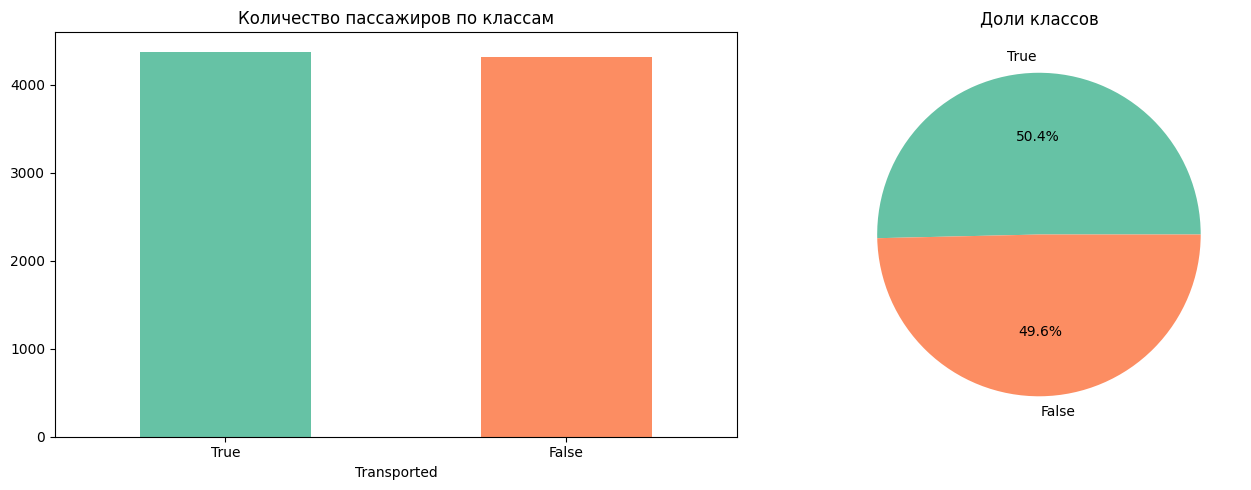

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette('Set2')
train[TARGET].value_counts().plot.bar(ax=axes[0], color=colors)
axes[0].set_title('Количество пассажиров по классам')
axes[0].tick_params(axis='x', rotation=0)
train[TARGET].value_counts(normalize=True).plot.pie(
    ax=axes[1], autopct='%1.1f%%', colors=colors
)
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

**Наблюдение:** Классы почти одинакового размера, поэтому accuracy подходит для сравнения моделей

### Распределения числовых признаков

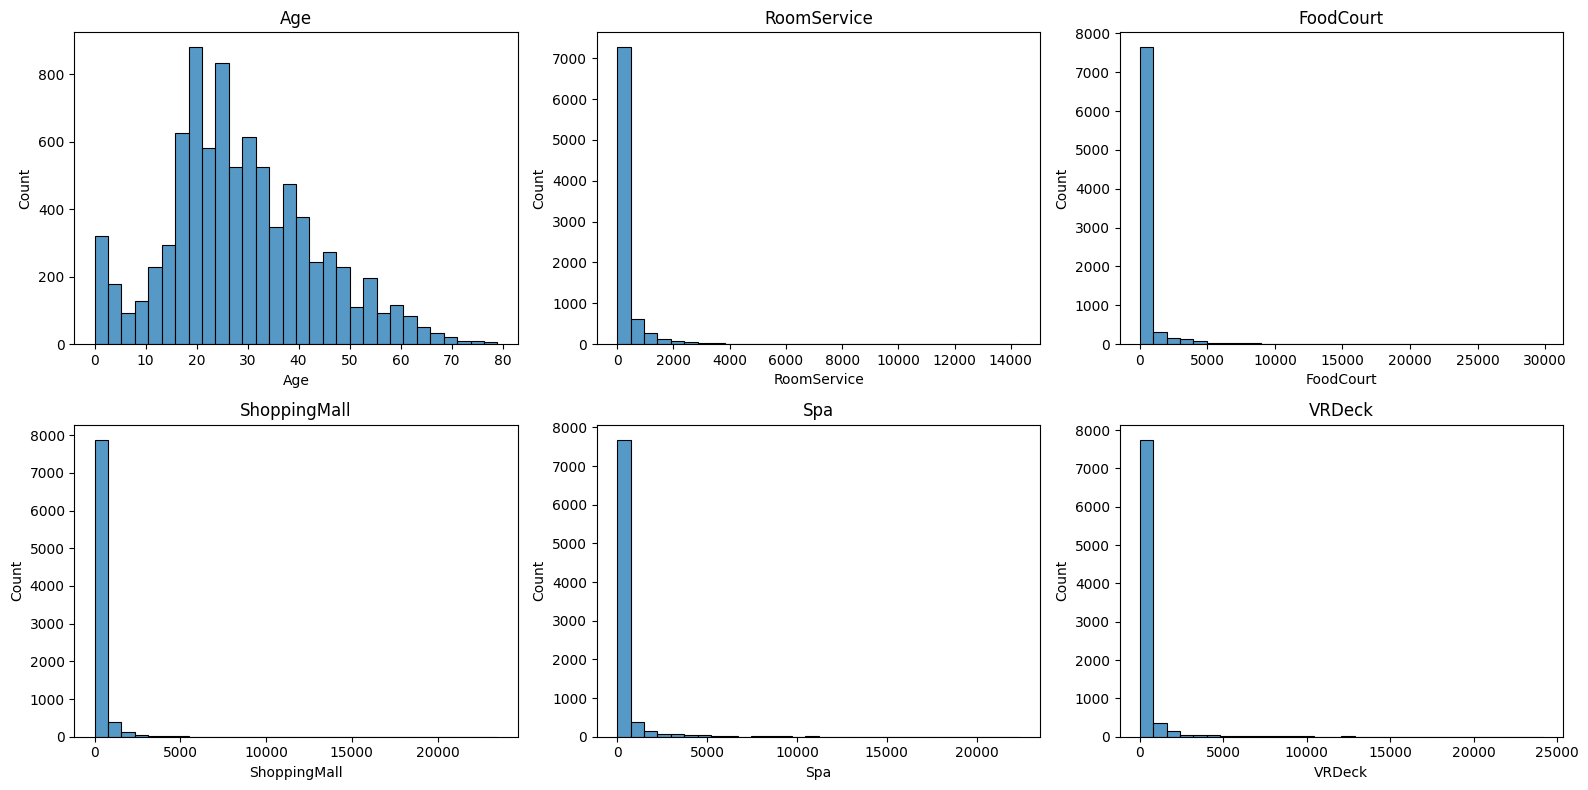

In [10]:
numeric_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(data=train, x=col, bins=30, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

**Наблюдение:** Почти все числовые признаки сосредоточены около нуля, большие значения встречаются редко

### Категориальные признаки

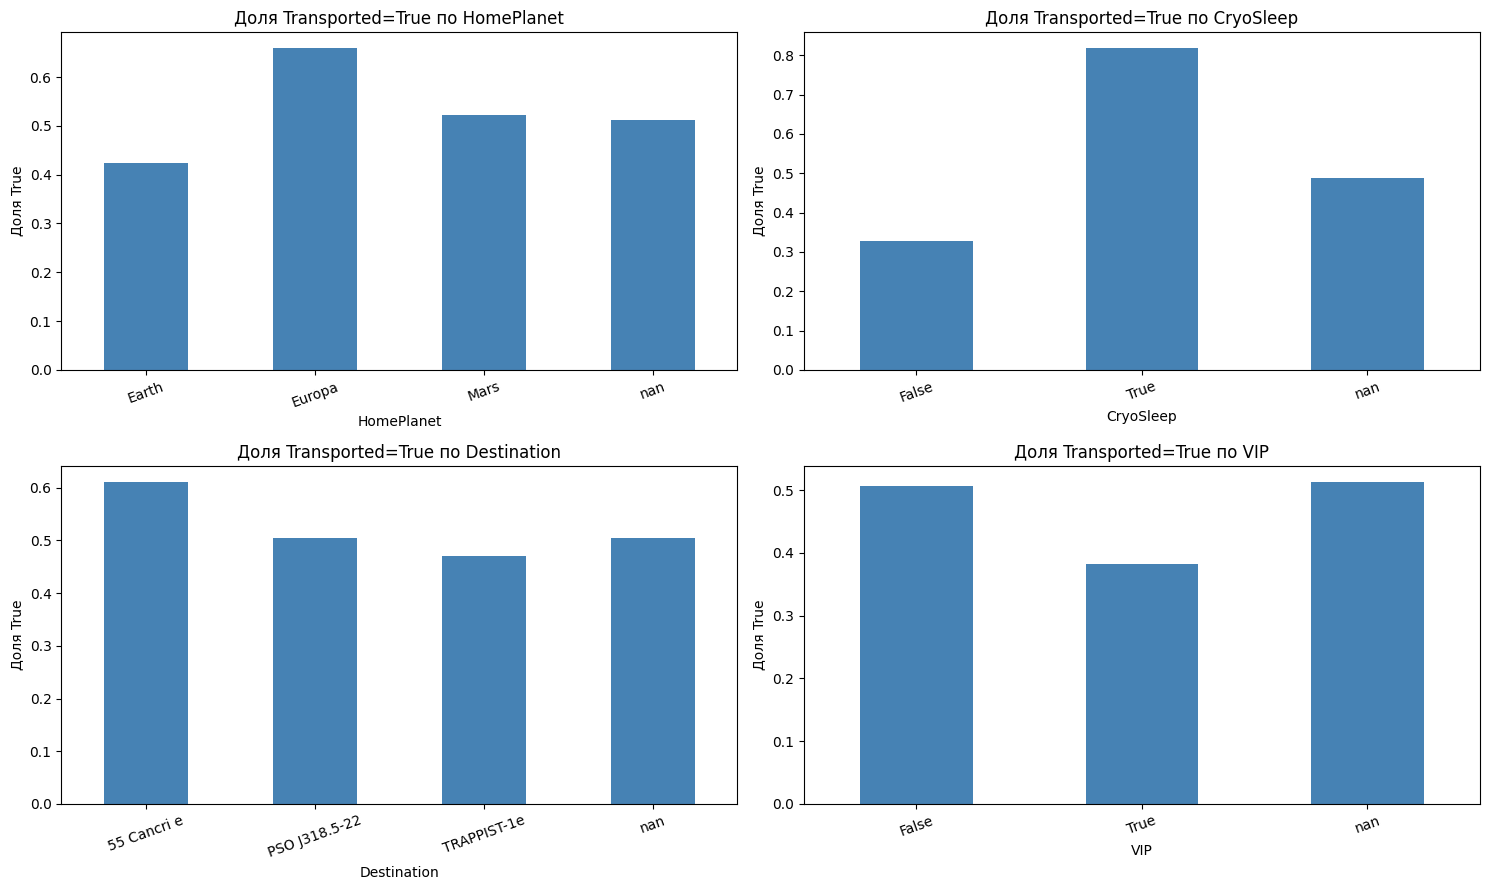

In [11]:
categorical_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    transported_rate = train.groupby(col, dropna=False)[TARGET].mean()
    transported_rate.plot.bar(ax=axes[i], color='steelblue')
    axes[i].set_title(f'Доля Transported=True по {col}')
    axes[i].set_ylabel('Доля True')
    axes[i].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

### Выбросы и корреляции

Отрицательных значений возраста: 0
Отрицательных значений расходов: 0
Максимальный возраст: 79.0
Максимальные общие расходы: 35987.0


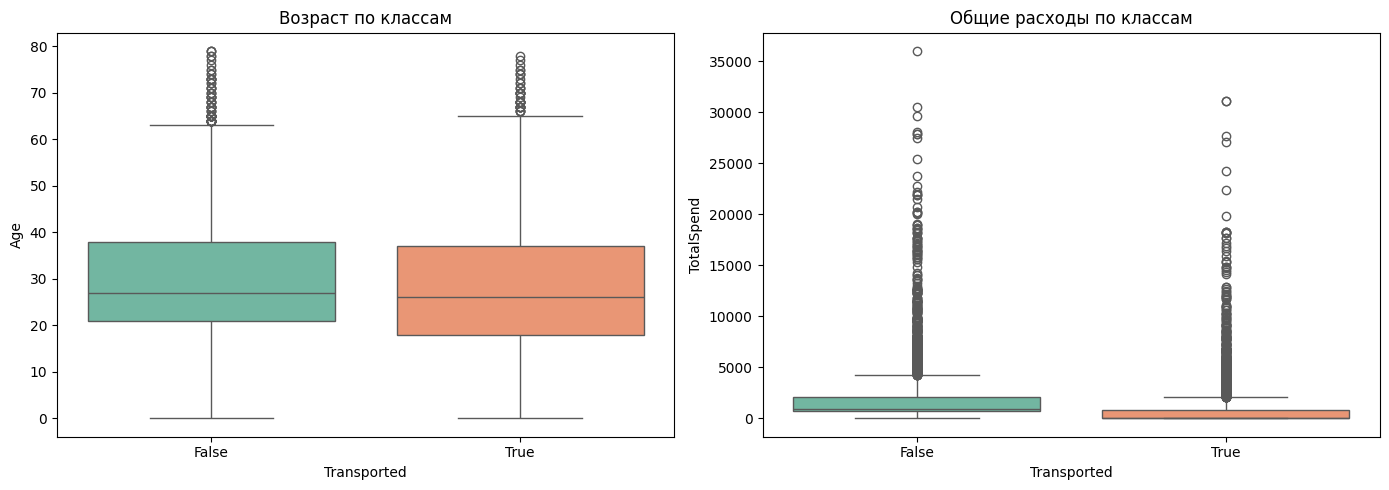

In [20]:
eda_df = train.copy()
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
eda_df['TotalSpend'] = eda_df[spend_cols].sum(
    axis=1, min_count=len(spend_cols)
)
print('Отрицательных значений возраста:', (eda_df['Age'] < 0).sum())
print('Отрицательных значений расходов:', (eda_df[spend_cols] < 0).sum().sum())
print('Максимальный возраст:', eda_df['Age'].max())
print('Максимальные общие расходы:', eda_df['TotalSpend'].max())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(
    data=eda_df,
    x=TARGET,
    y='Age',
    hue=TARGET,
    palette='Set2',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Возраст по классам')
sns.boxplot(
    data=eda_df,
    x=TARGET,
    y='TotalSpend',
    hue=TARGET,
    palette='Set2',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Общие расходы по классам')
plt.tight_layout()
plt.show()

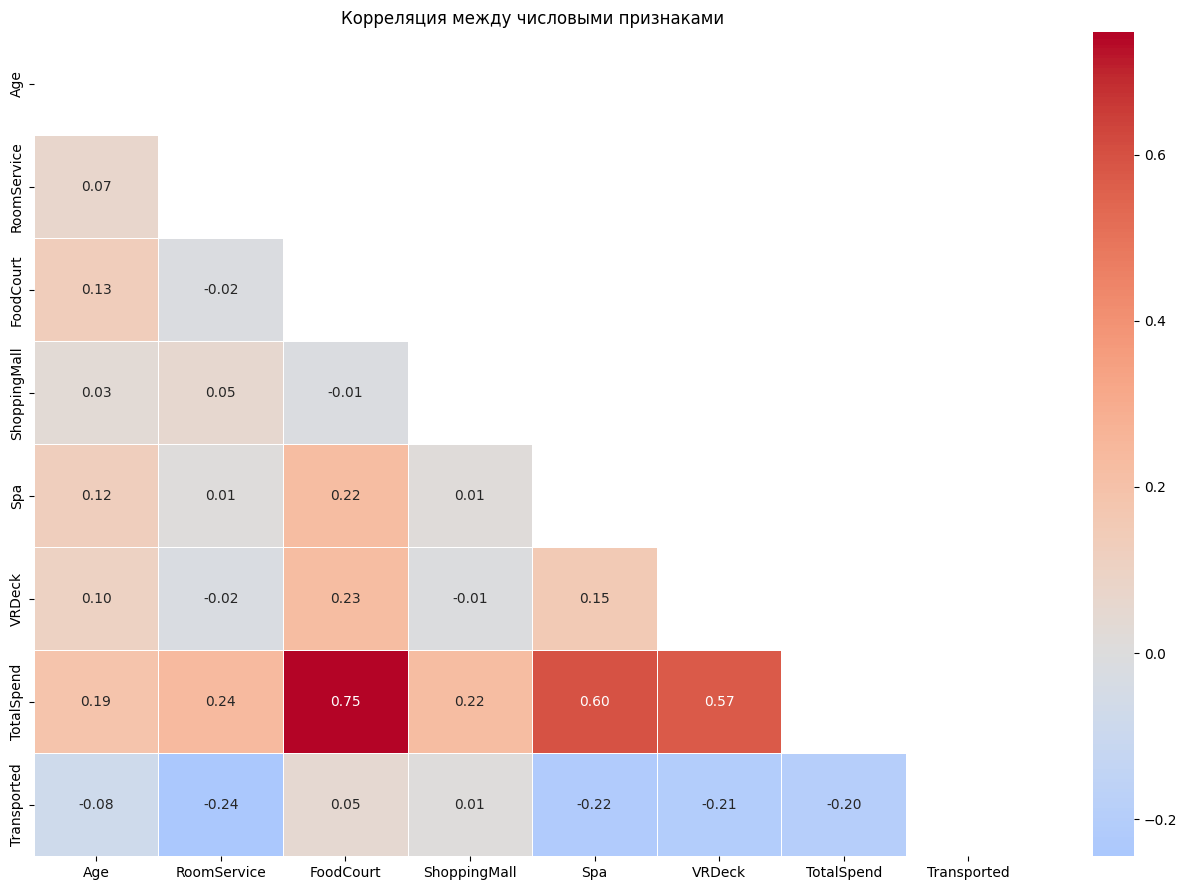

In [19]:
numeric_df = eda_df.select_dtypes(include=np.number).copy()
numeric_df[TARGET] = eda_df[TARGET].astype(int)
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(13, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5
)
plt.title('Корреляция между числовыми признаками')
plt.tight_layout()
plt.show()

## 4. Создание новых признаков

Добавим признаки, которые можно получить отдельно для каждого пассажира:

1. Номер пассажира внутри группы из `PassengerId`
2. Палубу, номер и сторону каюты из `Cabin`
3. Общие расходы и их логарифм
4. Отсутствие расходов
5. Детский возраст
6. Количество пропусков в строке

In [22]:
SPEND_COLS = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']


def add_features(df):
    df = df.copy()
    df['MissingCount'] = df.isnull().sum(axis=1)
    passenger_parts = df['PassengerId'].str.split('_', expand=True)
    df['GroupMember'] = pd.to_numeric(passenger_parts[1], errors='coerce')
    cabin_parts = df['Cabin'].str.split('/', expand=True)
    df['CabinDeck'] = cabin_parts[0]
    df['CabinNumber'] = pd.to_numeric(cabin_parts[1], errors='coerce')
    df['CabinSide'] = cabin_parts[2]
    df['TotalSpend'] = df[SPEND_COLS].sum(
        axis=1, min_count=len(SPEND_COLS)
    )
    df['LogTotalSpend'] = np.log1p(df['TotalSpend'])
    df['NoSpend'] = np.where(
        df['TotalSpend'].isnull(),
        np.nan,
        (df['TotalSpend'] == 0).astype(int)
    )
    df['IsChild'] = np.where(
        df['Age'].isnull(),
        np.nan,
        (df['Age'] < 13).astype(int)
    )
    return df.drop(columns=['PassengerId', 'Cabin', 'Name'])


X = add_features(train.drop(columns=TARGET))
X_kaggle = add_features(test)
y = train[TARGET].astype(int)
print('Количество признаков:', X.shape[1])
X.head()

Количество признаков: 19


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,MissingCount,GroupMember,CabinDeck,CabinNumber,CabinSide,TotalSpend,LogTotalSpend,NoSpend,IsChild
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,0,1,B,0.0,P,0.0,0.000000,1.0,0.0
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,0,1,F,0.0,S,736.0,6.602588,0.0,0.0
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,0,1,A,0.0,S,10383.0,9.248021,0.0,0.0
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,0,2,A,0.0,S,5176.0,8.551981,0.0,0.0
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,0,1,F,1.0,S,1091.0,6.995766,0.0,0.0


## 5. Подготовка данных

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = [col for col in X.columns if col not in numeric_features]
print('Train:', X_train.shape)
print('Local test:', X_test.shape)
print('Числовые признаки:', numeric_features)
print('Категориальные признаки:', categorical_features)

Train: (6954, 19)
Local test: (1739, 19)
Числовые признаки: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'MissingCount', 'GroupMember', 'CabinNumber', 'TotalSpend', 'LogTotalSpend', 'NoSpend', 'IsChild']
Категориальные признаки: ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'CabinDeck', 'CabinSide']


In [25]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('numeric', numeric_transformer, numeric_features),
    ('categorical', categorical_transformer, categorical_features)
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Числовые признаки заполняются медианой, а категориальные - самым частым значением

## 6. Baseline и сравнение моделей

Логистическую регрессию используем как baseline. Затем сравниваем её с деревом решений,
случайным лесом и градиентным бустингом. Для всех моделей считаем одну и ту же
5-fold CV accuracy

In [26]:
logreg = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
decision_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE))
])
random_forest = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=150, max_depth=12,
        random_state=RANDOM_STATE, n_jobs=1
    ))
])
gradient_boosting = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.05,
        max_depth=3, random_state=RANDOM_STATE
    ))
])
models = {
    'Logistic Regression': logreg,
    'Decision Tree': decision_tree,
    'Random Forest': random_forest,
    'Gradient Boosting': gradient_boosting
}
model_results = []
model_scores = {}
for name, model in models.items():
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring='accuracy', n_jobs=1
    )
    model_scores[name] = scores.mean()
    model_results.append({
        'Модель': name,
        'CV Accuracy': scores.mean(),
        'CV std': scores.std()
    })
model_results = pd.DataFrame(model_results).sort_values(
    'CV Accuracy', ascending=False
)
model_results.round(4)

,Модель,CV Accuracy,CV std
2,Random Forest,0.8026,0.0045
3,Gradient Boosting,0.7961,0.0076
0,Logistic Regression,0.7913,0.0020
1,Decision Tree,0.7660,0.0069


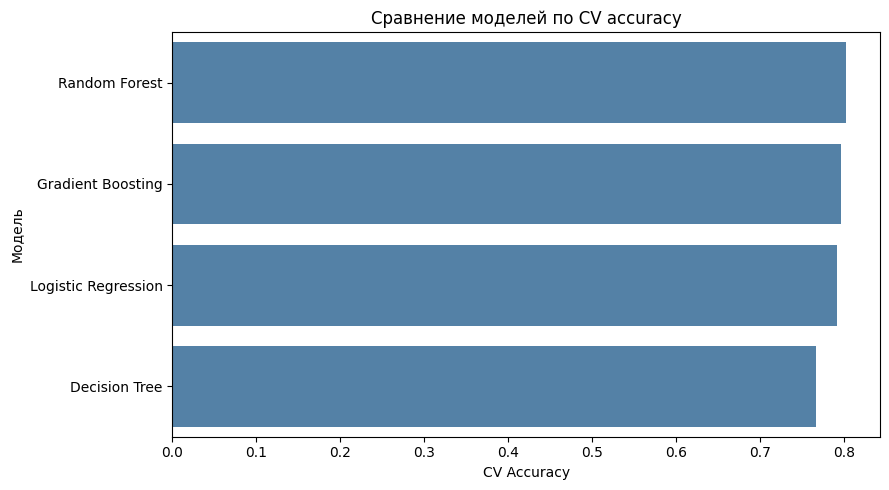

In [27]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=model_results,
    x='CV Accuracy', y='Модель', color='steelblue'
)
plt.title('Сравнение моделей по CV accuracy')
plt.tight_layout()
plt.show()

## 7. Подбор параметров Random Forest

In [28]:
params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [8, 12, None],
    'model__min_samples_leaf': [1, 2]
}
grid = GridSearchCV(
    random_forest,
    params,
    cv=cv,
    scoring='accuracy',
    n_jobs=1
)
grid.fit(X_train, y_train)
best_rf = grid.best_estimator_
model_scores['Random Forest tuned'] = grid.best_score_
print('Лучшие параметры:', grid.best_params_)
print('Лучший CV accuracy:', round(grid.best_score_, 4))

Лучшие параметры: {'model__max_depth': 12, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}
Лучший CV accuracy: 0.8051


## 8. Ансамбль Weighted Voting

Weighted voting усредняет вероятности логистической регрессии,
настроенного случайного леса и градиентного бустинга. Лесу и бустингу даём больший вес, потому что они могут находить нелинейные зависимости

In [30]:
voting = VotingClassifier(
    estimators=[
        ('logreg', logreg),
        ('rf', best_rf),
        ('gb', gradient_boosting)
    ],
    voting='soft',
    weights=[1, 2, 2],
    n_jobs=1
)
voting_scores = cross_val_score(
    voting, X_train, y_train,
    cv=cv, scoring='accuracy', n_jobs=1
)
model_scores['Weighted Voting'] = voting_scores.mean()
print('Weighted Voting CV accuracy:', round(voting_scores.mean(), 4))
print('CV std:', round(voting_scores.std(), 4))

Weighted Voting CV accuracy: 0.8034
CV std: 0.0044


## 9. Выбор модели и проверка на test

Лучшая модель по CV: Random Forest tuned
CV accuracy: 0.8051
Local test accuracy: 0.8039

Classification report:
              precision    recall  f1-score   support

           0       0.79      0.82      0.81       863
           1       0.82      0.79      0.80       876

    accuracy                           0.80      1739
   macro avg       0.80      0.80      0.80      1739
weighted avg       0.80      0.80      0.80      1739



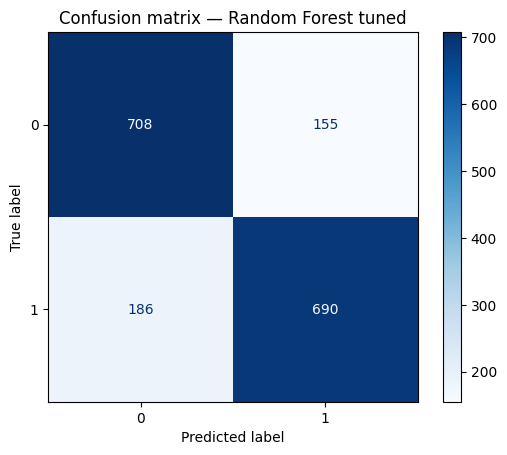

In [31]:
final_models = {
    **models,
    'Random Forest tuned': best_rf,
    'Weighted Voting': voting
}
best_model_name = max(model_scores, key=model_scores.get)
best_model = clone(final_models[best_model_name])
best_model.fit(X_train, y_train)
test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_pred)
print('Лучшая модель по CV:', best_model_name)
print('CV accuracy:', round(model_scores[best_model_name], 4))
print('Local test accuracy:', round(test_accuracy, 4))
print('\nClassification report:')
print(classification_report(y_test, test_pred))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred, cmap='Blues'
)
plt.title(f'Confusion matrix — {best_model_name}')
plt.show()

## 10. Обучение на всех данных и создание submission

In [32]:
final_model = clone(final_models[best_model_name])
final_model.fit(X, y)
kaggle_pred = final_model.predict(X_kaggle).astype(bool)
submission = sample_submission.copy()
submission[TARGET] = kaggle_pred
submission.to_csv('submission.csv', index=False)
print('Финальная модель:', best_model_name)
print('Размер submission:', submission.shape)
submission.head()

Финальная модель: Random Forest tuned
Размер submission: (4277, 2)


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
